# Full m6Anet training: validation-loss epoch selection

This notebook reads the logged full-training run. It does not retrain or evaluate test data.

- Selection uses the absolute lowest validation binary cross entropy.
- Patience uses a minimum improvement threshold. Fixed read samples reduce validation noise.
- Training loss uses balanced oversampling; validation uses natural prevalence.
- Data0 test remains unused. Earlier v1 models trained on those test sites.
- Historical pretrained/classical comparisons are not matched v2 training comparisons.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
from m6a_project.splitting import assert_disjoint

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
summary = json.loads((ROOT / "docs/results/m6anet_full_training.json").read_text())
run = ROOT / summary["run_path"]
split = pd.read_csv(run / "split.csv")
assert_disjoint(split)
assert summary["metrics"]["test_evaluated"] is False
display(pd.DataFrame(summary["split"]).T)
print(run)

,sites,genes,positive_sites,prevalence
test,24694.0,770.0,1107.0,0.044829
train,71794.0,2307.0,3265.0,0.045477
val,25350.0,775.0,1103.0,0.043511


/Users/ncduy/Git/dsa4262-project/experiments/data0_m6anet_full_v2/20261005T104640_official_m6anet_m6anet_scratch_c7794b10


Selected epoch: 15
Completed epochs: 20
Stopping reason: validation_loss_early_stopping


,epoch,train_loss,val_loss,train_roc_auc,val_roc_auc,val_pr_auc,train_seconds,validation_seconds,best_epoch,bad_epochs,checkpoint_improved
0,1,0.818342,0.449775,0.740850,0.864262,0.367877,19.568702,3.845161,1,0,True
1,2,0.436138,0.381573,0.879331,0.888678,0.411827,20.335433,3.698361,2,0,True
2,3,0.405789,0.378311,0.897603,0.897634,0.431754,19.225165,3.938745,3,0,True
3,4,0.391147,0.388298,0.905961,0.902990,0.442489,24.473815,3.753909,3,1,False
4,5,0.383238,0.375298,0.910020,0.904762,0.449829,21.948830,3.835877,5,0,True
5,6,0.378499,0.337661,0.912309,0.906820,0.451050,19.779603,3.706407,6,0,True
6,7,0.372718,0.355786,0.915411,0.908339,0.456142,18.488846,3.870114,6,1,False
7,8,0.367704,0.355130,0.917748,0.910387,0.458540,25.632661,5.015247,6,2,False
8,9,0.364858,0.343703,0.919207,0.911171,0.459527,19.701636,5.528203,6,3,False
9,10,0.362349,0.313644,0.920068,0.911824,0.460355,21.107756,3.937970,10,0,True


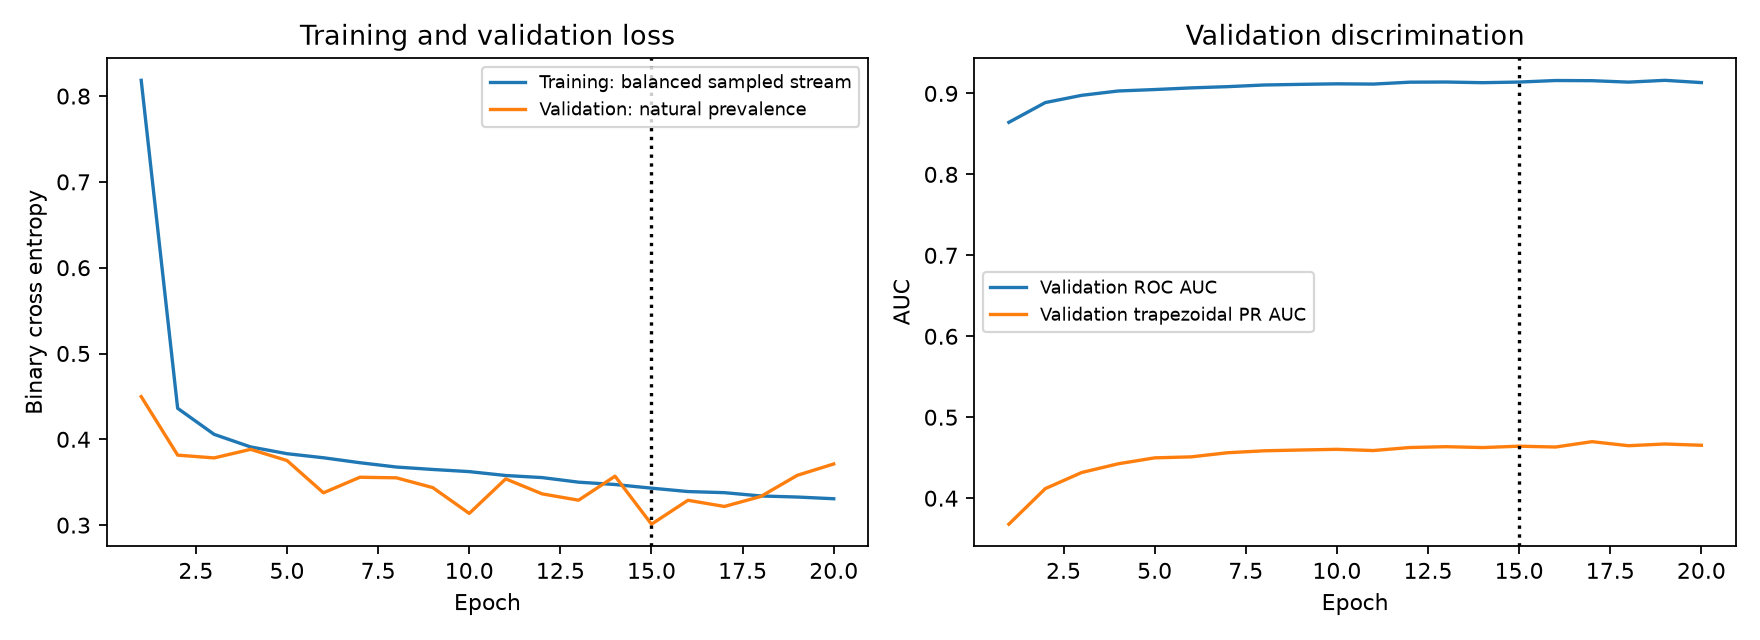

In [2]:
history = pd.read_csv(run / "official_output/history.csv")
timing = summary["timing"]
assert int(history.loc[history.val_loss.idxmin(), "epoch"]) == timing["best_epoch"]
print("Selected epoch:", timing["best_epoch"])
print("Completed epochs:", timing["epochs_completed"])
print("Stopping reason:", timing["stop_reason"])
display(history)
display(Image(filename=str(run / "learning_curves.png")))

In [3]:
display(pd.Series(summary["metrics"])[["average_precision", "roc_auc", "pr_auc_trapezoid", "log_loss", "brier_score", "total_seconds"]])
assert timing["checkpoint_predictions_reproduced"]
predictions = pd.read_parquet(run / "validation_predictions.parquet")
expected = split.query("partition == 'val'")
keys = ["transcript_id", "transcript_position"]
assert set(map(tuple, predictions[keys].to_numpy())) == set(map(tuple, expected[keys].to_numpy()))
display(predictions.head())

average_precision      0.464915
roc_auc                 0.91403
pr_auc_trapezoid       0.464229
log_loss               0.301076
brier_score            0.088343
total_seconds        664.958807
dtype: object

,transcript_id,transcript_position,n_reads,start,end,sequence,gene_id,label,partition,set_type,score,sampling_std
0,ENST00000000412,355,50,206793,209801,GAAACTA,ENSG00000003056,0,val,Val,0.023458,0.007779
1,ENST00000000412,367,47,209801,212634,GGGACCG,ENSG00000003056,0,val,Val,0.490322,0.037497
2,ENST00000000412,496,51,212634,215696,AGGACTG,ENSG00000003056,0,val,Val,0.241958,0.062827
3,ENST00000000412,501,56,215696,219051,TGGACTG,ENSG00000003056,0,val,Val,0.739321,0.089596
4,ENST00000000412,547,52,219051,222162,CAGACAG,ENSG00000003056,0,val,Val,0.198006,0.106071


The selected model and matching normalization are under `official_output/model_states.pt` and `official_output/train_norm_dict.joblib`. `checkpoint.pt` retains the selected epoch's optimizer/RNG state; `last_checkpoint.pt` retains the final epoch.

To start a fresh recorded experiment: `uv run python scripts/train_m6anet.py --config configs/experiments/m6anet_full.toml`. The default runner does not automatically score test data.